# protGPS on ClinVar: condensate localization variant effects

Loads the merged wild-type vs. mutant protGPS predictions (`clinvar_protgps_deltas.tsv`, built by `../12_variant_effect_prediction/localization_condensate/`) and does a first-pass sanity check + exploration.

**Data file is not checked into git** (766MB) — regenerate it by running the pipeline in `12_variant_effect_prediction/localization_condensate/`, specifically the delta-merge step, or pull `clinvar_protgps_deltas.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

COMPARTMENTS = [
    "NUCLEAR_SPECKLE", "P-BODY", "PML-BDOY", "POST_SYNAPTIC_DENSITY",
    "STRESS_GRANULE", "CHROMOSOME", "NUCLEOLUS", "NUCLEAR_PORE_COMPLEX",
    "CAJAL_BODY", "RNA_GRANULE", "CELL_JUNCTION", "TRANSCRIPTIONAL",
]

## Load data

In [2]:
df = pd.read_csv("clinvar_protgps_deltas.tsv", sep="\t")
print(f"{len(df):,} variant rows")
df.head()

2,587,382 variant rows


,VariationID,GeneID,GeneSymbol,accession,category,WT_NUCLEAR_SPECKLE,WT_P-BODY,WT_PML-BDOY,WT_POST_SYNAPTIC_DENSITY,WT_STRESS_GRANULE,...,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
0,2,9907,AP5Z1,NM_014855.3,delins,0.0000,0.0116,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.9908,0.0000,0.7170,0.0000,0.0,-0.6452,0.0000
1,4,9640,ZNF592,NM_014630.3,missense,0.0000,0.2241,0.0001,0.0000,0.0018,...,0.0001,0.0000,-0.0001,-0.0523,0.0001,-0.0005,0.0000,0.0,0.0000,0.0000
2,5,55572,FOXRED1,NM_017547.4,nonsense,0.1297,0.0141,0.0000,0.8014,0.0653,...,0.0000,-0.8014,-0.0653,0.9228,0.0000,0.0003,-0.0001,0.0,-0.0002,0.0000
3,6,55572,FOXRED1,NM_017547.4,missense,0.1297,0.0141,0.0000,0.8014,0.0653,...,0.0001,-0.3600,0.5214,0.0000,0.0000,0.0001,0.0000,0.0,0.0002,0.0003
4,214885,80224,NUBPL,NM_025152.3,missense,0.0000,0.0062,0.0000,0.0028,0.0008,...,0.0000,-0.0027,-0.0005,0.1134,0.0001,0.0211,0.0000,0.0,0.0000,0.0000


## Sanity check: known condensate marker genes (wild-type scores)

Checking a handful of textbook condensate proteins against their well-established localization. `COIL`/`FUS`/`G3BP1`/`TARDBP` matched expectations exactly when checked manually; `NPM1` (canonically nucleolar) did not — protGPS scored it as stress-granule-like instead. Worth keeping in mind as a known model limitation, not a pipeline bug (the WT sequence was independently verified correct).

In [3]:
known_genes = {
    "COIL": ("NM_004645.3", "CAJAL_BODY"),
    "FUS": ("NM_004960.4", "STRESS_GRANULE"),
    "G3BP1": ("NM_005754.3", "STRESS_GRANULE"),
    "NPM1": ("NM_002520.7", "NUCLEOLUS"),
    "TARDBP": ("NM_007375.4", "STRESS_GRANULE"),
}

wt_cols = [f"WT_{c}" for c in COMPARTMENTS]
for gene, (acc, expected) in known_genes.items():
    rows = df[df["accession"] == acc]
    if rows.empty:
        print(f"{gene} ({acc}): no variant rows in this table (no missense/etc. built for it)")
        continue
    wt_scores = rows.iloc[0][wt_cols]
    top = wt_scores.astype(float).idxmax().replace("WT_", "")
    top_score = wt_scores.astype(float).max()
    match = "OK" if top == expected else "MISMATCH"
    print(f"{gene:8s} ({acc}): top={top:22s} ({top_score:.3f})  expected={expected:15s}  [{match}]")

COIL     (NM_004645.3): top=CAJAL_BODY             (0.992)  expected=CAJAL_BODY       [OK]
FUS      (NM_004960.4): top=STRESS_GRANULE         (0.874)  expected=STRESS_GRANULE   [OK]
G3BP1    (NM_005754.3): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]


NPM1     (NM_002520.7): top=STRESS_GRANULE         (0.998)  expected=NUCLEOLUS        [MISMATCH]
TARDBP   (NM_007375.4): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]


## Wild-type score distributions

Most proteins should score near 0 for most compartments (condensate-specific localization is the exception, not the rule).

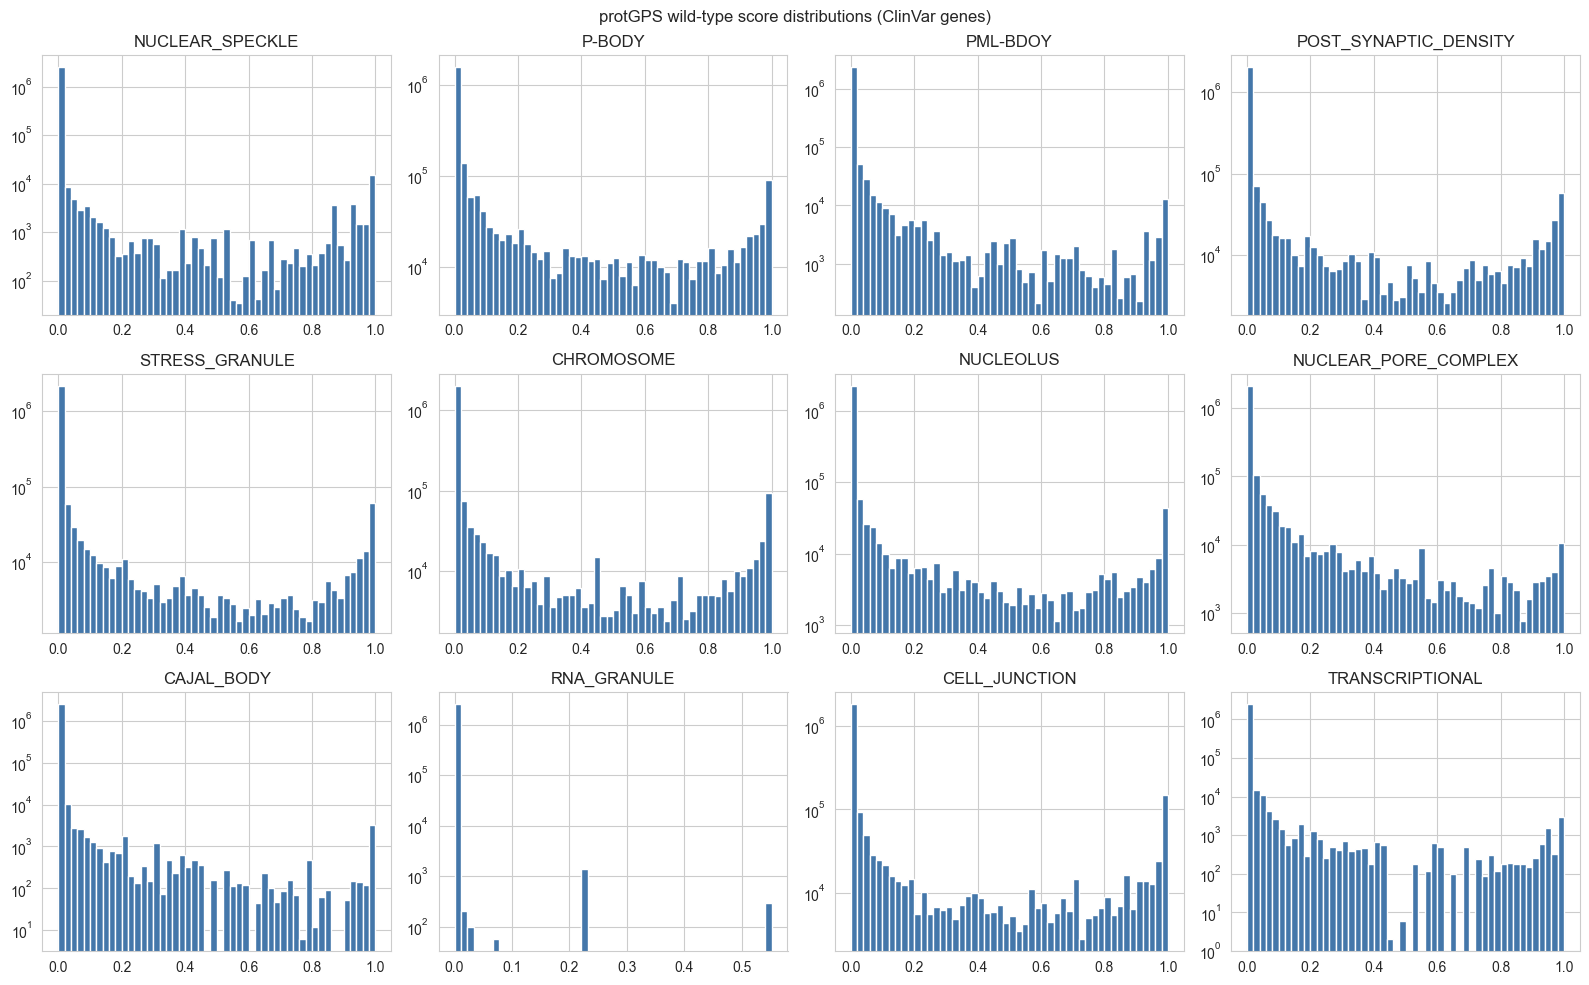

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"WT_{c}"], bins=50, color="#4477AA")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS wild-type score distributions (ClinVar genes)")
fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

`DELTA = mutant_score - WT_score`. Most variants should have near-zero delta (no predicted change in condensate association); the tails are the interesting cases.

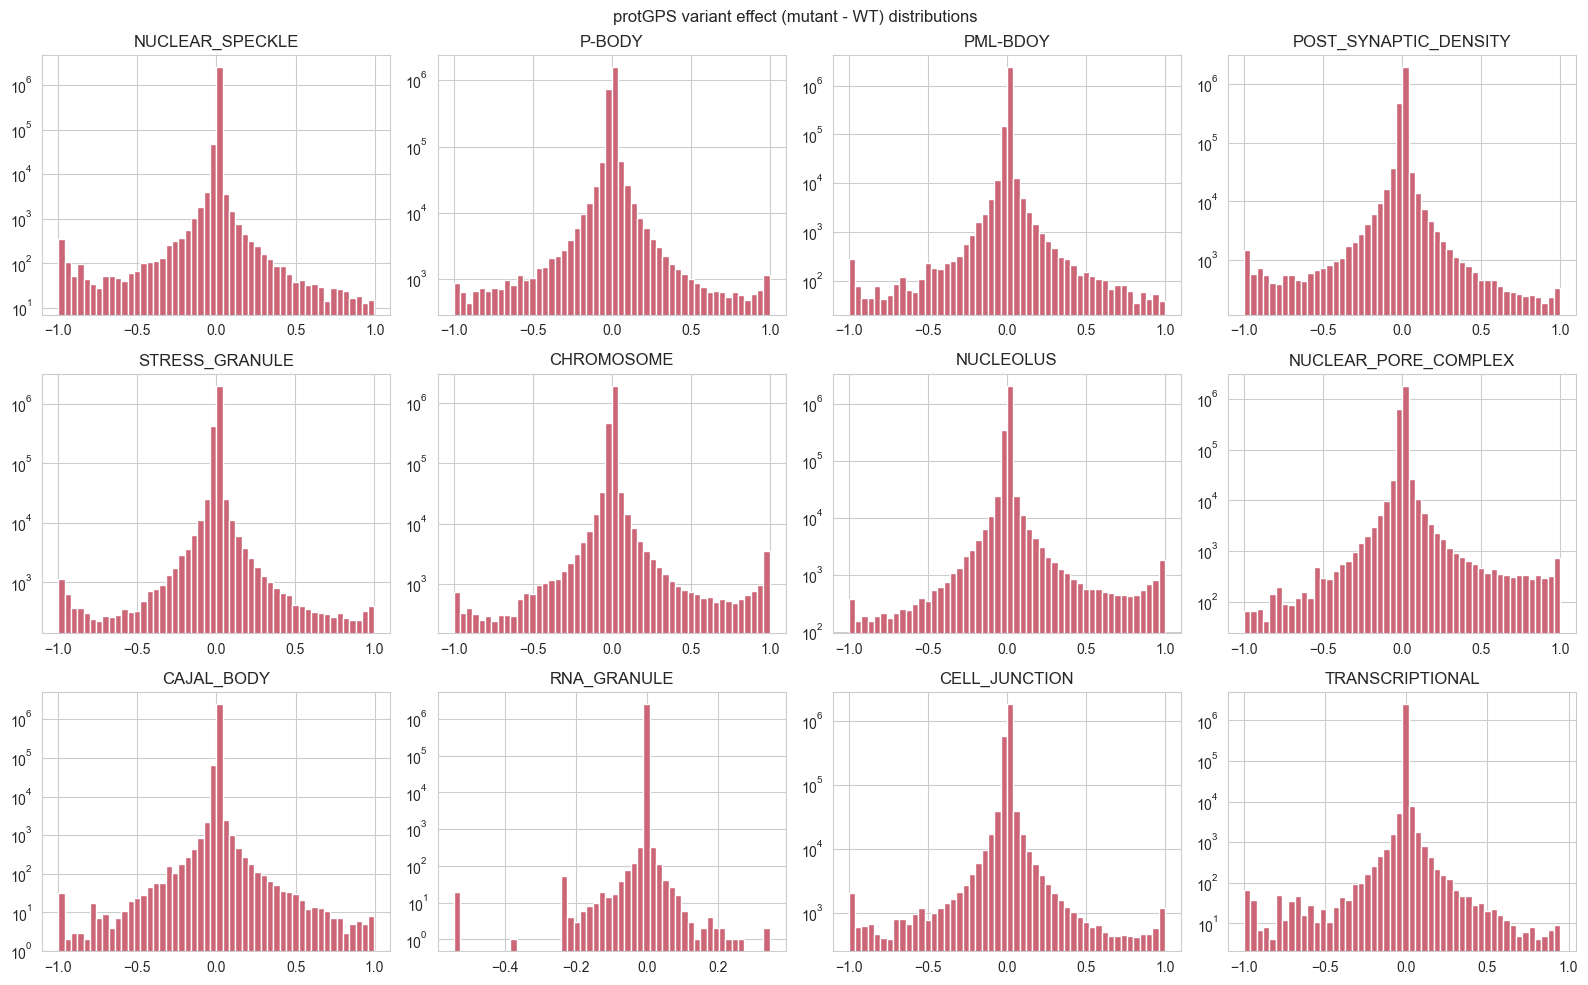

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"DELTA_{c}"], bins=50, color="#CC6677")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS variant effect (mutant - WT) distributions")
fig.tight_layout()
plt.show()

## Variants with the largest predicted condensate-localization change

Ranked by the single largest absolute delta across any compartment — these are the variants protGPS predicts most strongly alter condensate association.

In [6]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
top_variants = df.loc[max_abs_delta.sort_values(ascending=False).index[:25]]
top_variants[["VariationID", "GeneSymbol", "category", "accession"] + delta_cols].head(25)

,VariationID,GeneSymbol,category,accession,DELTA_NUCLEAR_SPECKLE,DELTA_P-BODY,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
277012,854137,NTRK1,nonsense,NM_002529.4,0.0002,0.0000,0.0001,0.0066,0.0003,0.0035,0.1417,0.0000,0.0000,0.0,-1.0000,0.0000
1768858,3593499,COL11A2,delins,NM_080680.3,0.0000,-0.0037,0.0000,-0.0857,0.0000,0.5448,1.0000,0.0000,0.0000,0.0,-0.0212,0.0000
317075,915274,TDP2,nonsense,NM_016614.3,0.0000,0.0000,0.0000,0.0000,0.0000,0.9993,-1.0000,0.7881,0.0000,0.0,0.0002,0.0000
436720,1192511,ERCC4,nonsense,NM_005236.3,0.0000,0.0015,0.6799,0.0000,0.0012,-1.0000,0.0000,0.0007,0.0008,0.0,0.0001,0.0011
691150,1805942,CUL3,nonsense,NM_003590.5,-1.0000,0.4460,0.0067,0.0002,0.0339,0.0000,-0.0001,0.0002,-0.0142,0.0,0.0000,0.0000
6104,9231,DSC3,nonsense,NM_001941.5,0.0000,0.0000,0.0000,0.9982,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,-1.0000,0.0000
11267,16851,DNASE1,nonsense,NM_005223.4,0.0000,-0.1390,0.0000,-0.7362,-0.0001,1.0000,0.0067,0.0001,0.0000,0.0,-0.0164,0.0000
1045308,2432810,POLG,nonsense,NM_002693.3,0.0000,-0.7835,0.0000,0.0000,-0.0001,1.0000,-0.1030,0.0015,0.0000,0.0,-0.0002,0.0000
136162,451713,CTNNB1,nonsense,NM_001904.4,0.0000,-0.0001,0.0000,0.0000,0.0000,0.9951,0.0000,0.0498,0.0000,0.0,-1.0000,0.0000
532311,1477377,CRYBA4,nonsense,NM_001886.3,0.0000,-0.1560,0.0000,0.0000,0.0000,1.0000,-0.0004,0.8319,0.0000,0.0,-0.8107,0.0000
